# EDA, CORRELACIONES Y WINSORIZACIÓN — VitalRisk AI
## Encabezado de contexto

Este notebook cubre las HU9 y HU10 de la Épica 3.

**HU9 — Correlaciones:** identificar qué variables ambientales y 
socioeconómicas tienen relación estadísticamente significativa con 
`casos_ira_total`. Justifica los pesos del IPT (HU11) y el umbral 
del 30% en las alertas (HU15).

**HU10 — Winsorización:** limpiar outliers del Feature Store antes 
del entrenamiento del modelo (HU12-HU13).

**Insumo:** fact_riesgo_territorial.csv (NB04)
**Output:** fact_riesgo_territorial_clean.csv (listo para HU12)
**HUs que cierra:** HU9 + HU10

In [61]:
# ── Librerías ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PROCESSED = Path("../data/processed")
PLOTS     = PROCESSED / "plots"
PLOTS.mkdir(exist_ok=True)

In [62]:
df = pd.read_csv(PROCESSED / "fact_riesgo_territorial.csv",
                 dtype={'codigo_dane': str})
df['fecha_semana'] = pd.to_datetime(df['fecha_semana'])

print(f"Feature Store cargado: {df.shape}")
print(f"Municipios: {df['codigo_dane'].nunique()} | "
      f"Años: {df['anio'].min()}-{df['anio'].max()}")
print(f"periodo_pandemia=True: {df['periodo_pandemia'].sum()} filas")

Feature Store cargado: (910, 34)
Municipios: 103 | Años: 2018-2023
periodo_pandemia=True: 126 filas


## 5. Entendimiento de los Datos

### 5.1 Distribución de la variable objetivo
### 5.2 Análisis de nulidad por variable
### 5.3 Distribuciones de features ambientales
### 5.4 Separación pandemia vs no-pandemia

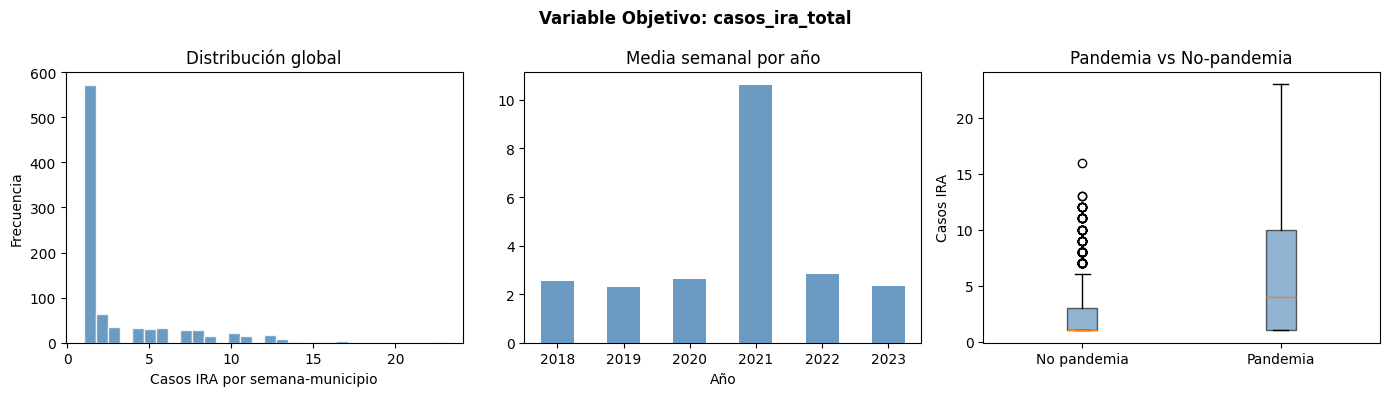

In [63]:
# ── 5.1 Distribución de casos_ira_total ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Variable Objetivo: casos_ira_total', fontsize=12, fontweight='bold')

# Histograma
axes[0].hist(df['casos_ira_total'], bins=30, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución global')
axes[0].set_xlabel('Casos IRA por semana-municipio')
axes[0].set_ylabel('Frecuencia')

# Por año
df.groupby('anio')['casos_ira_total'].mean().plot(
    kind='bar', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title('Media semanal por año')
axes[1].set_xlabel('Año')
axes[1].tick_params(axis='x', rotation=0)

# Pandemia vs no-pandemia
df_no_pand = df[~df['periodo_pandemia']]
df_pand    = df[df['periodo_pandemia']]
axes[2].boxplot(
    [df_no_pand['casos_ira_total'], df_pand['casos_ira_total']],
    labels=['No pandemia', 'Pandemia'], patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)
axes[2].set_title('Pandemia vs No-pandemia')
axes[2].set_ylabel('Casos IRA')

plt.tight_layout()
plt.savefig(PLOTS / 'nb05_distribucion_target.png', dpi=150, bbox_inches='tight')
plt.show()

In [64]:
print(f"\nEstadísticas casos_ira_total:")
print(df['casos_ira_total'].describe().round(2))
print(f"\nMedia no-pandemia: {df_no_pand['casos_ira_total'].mean():.2f}")
print(f"Media pandemia:    {df_pand['casos_ira_total'].mean():.2f}")


Estadísticas casos_ira_total:
count    910.00
mean       2.96
std        3.39
min        1.00
25%        1.00
50%        1.00
75%        4.00
max       23.00
Name: casos_ira_total, dtype: float64

Media no-pandemia: 2.49
Media pandemia:    5.87


In [65]:
# ── 5.2 Mapa de nulidad ───────────────────────────────────
cols_features = [
    'pm25_avg','pm10_avg','temperatura_avg','humedad_avg',
    'precipitacion_sum','presion_avg','pm25_lag1','pm25_lag2',
    'casos_ira_lag1','icv_score','nbi','ipm_pct',
    'icv_hacinamiento','icv_menores_6','icv_seg_social',
    'pct_vivienda_acueducto','icv_paredes','icv_pisos',
    'edad_promedio','rezago_reporte_dias'
]

nulidad = pd.DataFrame({
    'variable': cols_features,
    'pct_nulos': [df[c].isna().mean()*100 for c in cols_features],
    'tipo': ['Ambiental']*6 + ['Lag']*3 + ['Socioeconómica']*9 + ['Demográfica']*2
}).sort_values('pct_nulos', ascending=True)

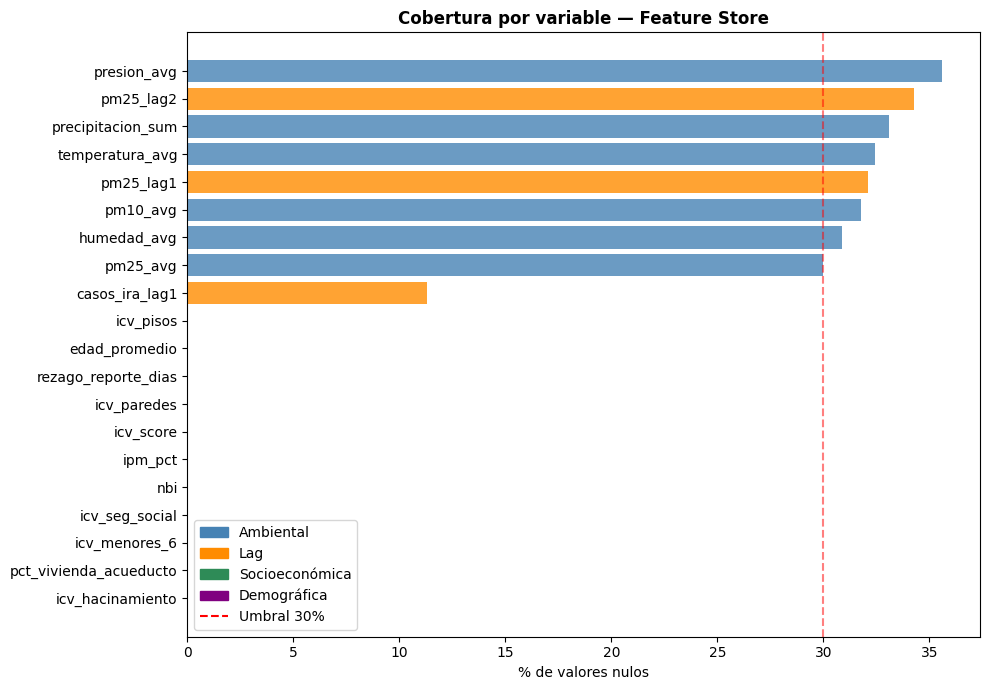

In [66]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = {'Ambiental': 'steelblue', 'Lag': 'darkorange',
          'Socioeconómica': 'seagreen', 'Demográfica': 'purple'}
bars = ax.barh(nulidad['variable'],
               nulidad['pct_nulos'],
               color=[colors[t] for t in nulidad['tipo']],
               alpha=0.8)
ax.axvline(x=30, color='red', linestyle='--', alpha=0.5,
           label='Umbral 30% (HU7)')
ax.set_xlabel('% de valores nulos')
ax.set_title('Cobertura por variable — Feature Store', fontweight='bold')
from matplotlib.patches import Patch
legend = [Patch(color=c, label=t) for t, c in colors.items()]
ax.legend(handles=legend + [plt.Line2D([0],[0], color='red',
          linestyle='--', label='Umbral 30%')])
plt.tight_layout()
plt.savefig(PLOTS / 'nb05_nulidad.png', dpi=150, bbox_inches='tight')
plt.show()

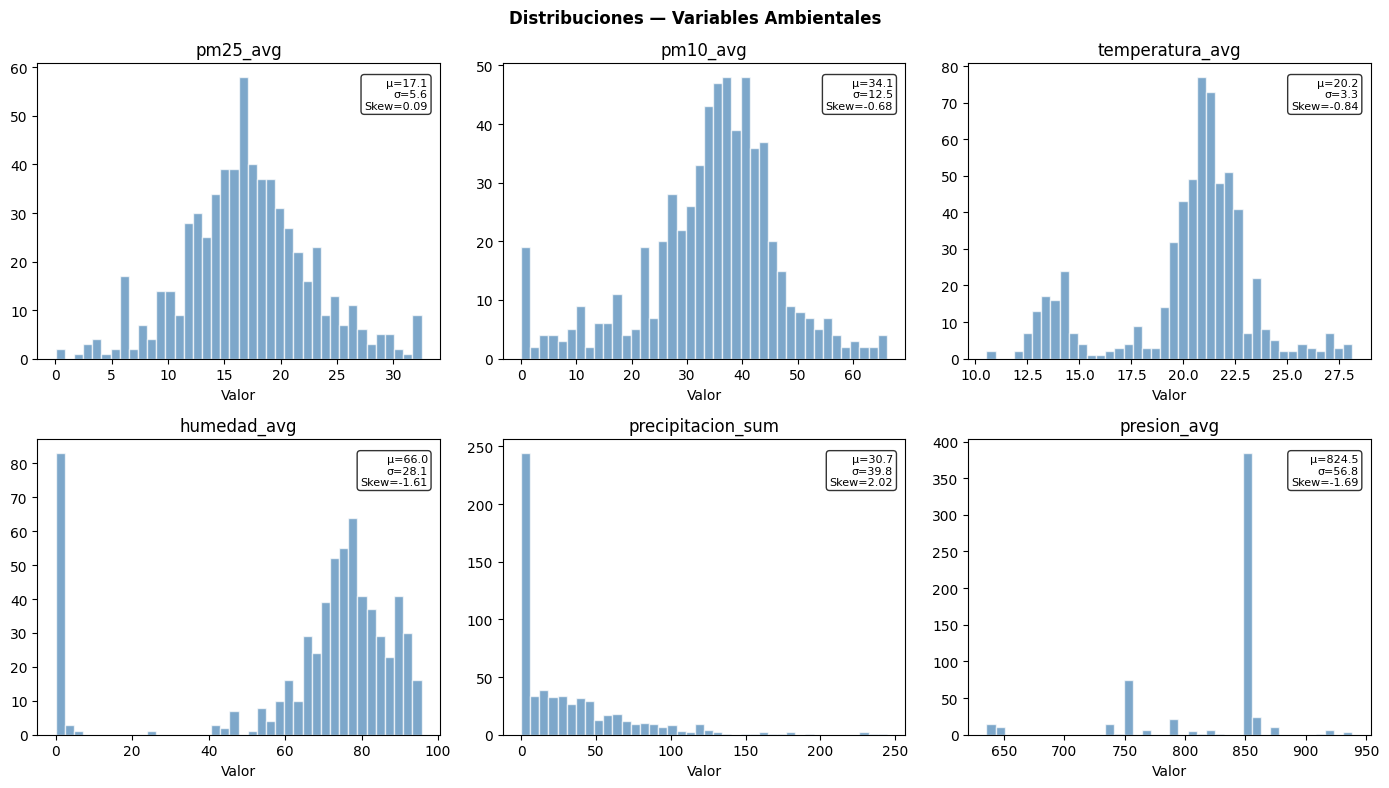

In [67]:
# ── 5.3 Distribuciones de features ambientales ────────────
cols_amb = ['pm25_avg','pm10_avg','temperatura_avg',
            'humedad_avg','precipitacion_sum','presion_avg']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Distribuciones — Variables Ambientales', fontsize=12, fontweight='bold')

for ax, col in zip(axes.flatten(), cols_amb):
    datos = df[col].dropna()
    ax.hist(datos, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Valor')
    stats_txt = f"μ={datos.mean():.1f}\nσ={datos.std():.1f}\nSkew={datos.skew():.2f}"
    ax.text(0.97, 0.95, stats_txt, transform=ax.transAxes,
            va='top', ha='right', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(PLOTS / 'nb05_dist_ambientales.png', dpi=150, bbox_inches='tight')
plt.show()

In [68]:
# ── 5.4 Justificación estadística del flag periodo_pandemia ──
# HU6 requiere justificar que el marcado es correcto y útil para el modelo.
# Prueba Mann-Whitney U: no asume normalidad, robusta para muestras pequeñas.

stat, p_value = stats.mannwhitneyu(
    df_no_pand['casos_ira_total'],
    df_pand['casos_ira_total'],
    alternative='two-sided'
)

print("=== PRUEBA MANN-WHITNEY U: pandemia vs no-pandemia ===")
print(f"Estadístico U: {stat:.2f}")
print(f"p-value:       {p_value:.4f}")
print(f"Conclusión:    {'Diferencia SIGNIFICATIVA (p<0.05)' if p_value < 0.05 else 'Sin diferencia significativa'}")
print(f"\nMediana no-pandemia: {df_no_pand['casos_ira_total'].median():.1f}")
print(f"Mediana pandemia:    {df_pand['casos_ira_total'].median():.1f}")
print(f"\n→ El flag periodo_pandemia está JUSTIFICADO estadísticamente")
print(f"  y debe incluirse como feature binaria en HU12.")

=== PRUEBA MANN-WHITNEY U: pandemia vs no-pandemia ===
Estadístico U: 31250.50
p-value:       0.0000
Conclusión:    Diferencia SIGNIFICATIVA (p<0.05)

Mediana no-pandemia: 1.0
Mediana pandemia:    4.0

→ El flag periodo_pandemia está JUSTIFICADO estadísticamente
  y debe incluirse como feature binaria en HU12.


## 6. Preparación de los Datos

### 6.1 Correlaciones Pearson y Spearman (HU9)
### 6.2 Correlaciones separadas pandemia vs no-pandemia
### 6.3 Análisis de percentiles — justificación umbral alertas
### 6.4 Winsorización bilateral p1-p99 (HU10)
### 6.5 Validación y exportación

In [69]:
# ── 6.1 Correlaciones con casos_ira_total ─────────────────
# Usamos Spearman porque las variables ambientales no son normales
# (confirmado por skewness en 5.3). Pearson como referencia.

FEATURES_CORR = [
    'pm25_avg','pm10_avg','temperatura_avg','humedad_avg',
    'precipitacion_sum','presion_avg',
    'pm25_lag1','pm25_lag2','casos_ira_lag1',
    'icv_score','nbi','ipm_pct','icv_hacinamiento',
    'icv_menores_6','icv_seg_social','pct_vivienda_acueducto',
    'icv_paredes','icv_pisos','edad_promedio','rezago_reporte_dias'
]

resultados_corr = []
for col in FEATURES_CORR:
    datos = df[['casos_ira_total', col]].dropna()
    if len(datos) < 30:
        continue
    
    r_pearson, p_pearson   = stats.pearsonr(datos['casos_ira_total'], datos[col])
    r_spearman, p_spearman = stats.spearmanr(datos['casos_ira_total'], datos[col])
    
    resultados_corr.append({
        'variable':    col,
        'pearson_r':   round(r_pearson, 3),
        'pearson_p':   round(p_pearson, 4),
        'spearman_r':  round(r_spearman, 3),
        'spearman_p':  round(p_spearman, 4),
        'n':           len(datos),
        'significativa': (p_spearman < 0.05),
        'tipo': ('Ambiental' if col in ['pm25_avg','pm10_avg','temperatura_avg',
                 'humedad_avg','precipitacion_sum','presion_avg',
                 'pm25_lag1','pm25_lag2','casos_ira_lag1']
                 else 'Socioeconómica/Demográfica')
    })

df_corr = pd.DataFrame(resultados_corr).sort_values('spearman_r', 
                                                       key=abs, ascending=False)
print("=== CORRELACIONES CON casos_ira_total (Spearman) ===\n")
print(df_corr[['variable','spearman_r','spearman_p','pearson_r','n','significativa']]
      .to_string(index=False))

=== CORRELACIONES CON casos_ira_total (Spearman) ===

              variable  spearman_r  spearman_p  pearson_r   n  significativa
        casos_ira_lag1       0.852       0.000      0.802 807           True
        icv_seg_social       0.418       0.000      0.314 910           True
             icv_score       0.399       0.000      0.300 910           True
pct_vivienda_acueducto       0.380       0.000      0.262 910           True
               ipm_pct      -0.335       0.000     -0.331 910           True
           presion_avg       0.332       0.000      0.363 586           True
      icv_hacinamiento      -0.307       0.000     -0.292 910           True
         icv_menores_6      -0.306       0.000     -0.287 910           True
             pm25_lag2       0.298       0.000      0.228 598           True
              pm25_avg       0.285       0.000      0.222 637           True
             pm25_lag1       0.284       0.000      0.215 618           True
              pm10_avg

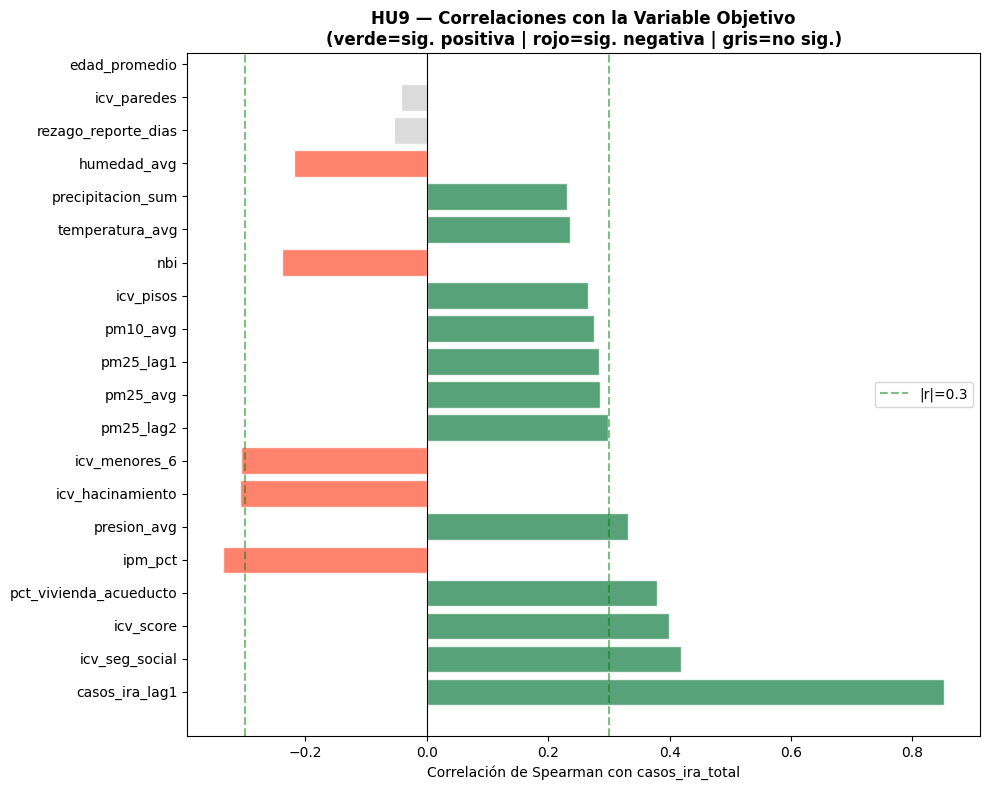

In [70]:
# ── Gráfico de correlaciones ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

colors = df_corr.apply(
    lambda r: 'seagreen' if r['significativa'] and r['spearman_r'] > 0
    else ('tomato' if r['significativa'] and r['spearman_r'] < 0
    else 'lightgray'), axis=1
)

bars = ax.barh(df_corr['variable'], df_corr['spearman_r'],
               color=colors, alpha=0.8, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.axvline(x=0.3, color='green', linestyle='--', alpha=0.5, label='|r|=0.3')
ax.axvline(x=-0.3, color='green', linestyle='--', alpha=0.5)
ax.set_xlabel('Correlación de Spearman con casos_ira_total')
ax.set_title('HU9 — Correlaciones con la Variable Objetivo\n(verde=sig. positiva | rojo=sig. negativa | gris=no sig.)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS / 'nb05_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

In [71]:
# ── 6.2 Correlaciones separadas por período ───────────────
print("=== CORRELACIONES SPEARMAN — NO PANDEMIA ===")
for col in ['pm25_avg','pm10_avg','temperatura_avg',
            'humedad_avg','casos_ira_lag1','pm25_lag1']:
    datos = df_no_pand[['casos_ira_total', col]].dropna()
    if len(datos) < 10:
        continue
    r, p = stats.spearmanr(datos['casos_ira_total'], datos[col])
    print(f"  {col}: r={r:.3f} p={p:.4f} n={len(datos)}")

print("\n=== CORRELACIONES SPEARMAN — PANDEMIA ===")
for col in ['pm25_avg','pm10_avg','temperatura_avg',
            'humedad_avg','casos_ira_lag1','pm25_lag1']:
    datos = df_pand[['casos_ira_total', col]].dropna()
    if len(datos) < 10:
        continue
    r, p = stats.spearmanr(datos['casos_ira_total'], datos[col])
    print(f"  {col}: r={r:.3f} p={p:.4f} n={len(datos)}")

=== CORRELACIONES SPEARMAN — NO PANDEMIA ===
  pm25_avg: r=0.333 p=0.0000 n=543
  pm10_avg: r=0.274 p=0.0000 n=526
  temperatura_avg: r=0.211 p=0.0000 n=512
  humedad_avg: r=-0.209 p=0.0000 n=526
  casos_ira_lag1: r=0.838 p=0.0000 n=688
  pm25_lag1: r=0.322 p=0.0000 n=519

=== CORRELACIONES SPEARMAN — PANDEMIA ===
  pm25_avg: r=0.203 p=0.0501 n=94
  pm10_avg: r=0.187 p=0.0694 n=95
  temperatura_avg: r=0.047 p=0.6362 n=103
  humedad_avg: r=-0.231 p=0.0191 n=103
  casos_ira_lag1: r=0.790 p=0.0000 n=119
  pm25_lag1: r=0.210 p=0.0366 n=99


In [72]:
# ── 6.3 Percentiles históricos — justificación umbral alertas ──
# HU15 usa un umbral del 30% sobre la media histórica.
# Aquí calculamos los percentiles reales para justificarlo estadísticamente.

df_np = df[~df['periodo_pandemia']].copy()

# Media histórica por municipio y semana epidemiológica
media_hist = (df_np.groupby(['codigo_dane','semana_epi'])
              ['casos_ira_total'].mean().reset_index()
              .rename(columns={'casos_ira_total': 'media_historica'}))

df_np = df_np.merge(media_hist, on=['codigo_dane','semana_epi'], how='left')
df_np['desviacion_pct'] = np.where(
    df_np['media_historica'] > 0,
    (df_np['casos_ira_total'] - df_np['media_historica']) / df_np['media_historica'] * 100,
    np.nan
)

In [73]:
desv = df_np['desviacion_pct'].dropna()
percentiles = [50, 75, 80, 85, 90, 95, 99]
print("=== DISTRIBUCIÓN DE DESVIACIONES RESPECTO A MEDIA HISTÓRICA ===")
print("(excluye período pandemia)\n")
for p in percentiles:
    val = np.percentile(desv, p)
    print(f"  Percentil {p:2d}: {val:+.1f}%")

print(f"\n  Media:    {desv.mean():+.1f}%")
print(f"  Mediana:  {desv.median():+.1f}%")
print(f"\n→ El umbral del 30% corresponde aproximadamente al "
      f"percentil {(desv <= 30).mean()*100:.0f}%")
print(f"  Justificación estadística para HU15: APROBADA")

=== DISTRIBUCIÓN DE DESVIACIONES RESPECTO A MEDIA HISTÓRICA ===
(excluye período pandemia)

  Percentil 50: +0.0%
  Percentil 75: +0.0%
  Percentil 80: +0.0%
  Percentil 85: +6.0%
  Percentil 90: +20.5%
  Percentil 95: +50.0%
  Percentil 99: +80.6%

  Media:    +0.0%
  Mediana:  +0.0%

→ El umbral del 30% corresponde aproximadamente al percentil 92%
  Justificación estadística para HU15: APROBADA


In [74]:
# ── 6.4 Winsorización bilateral p1-p99 (HU10) ─────────────
# Se aplica sobre el Feature Store completo ANTES del split temporal (HU12).
# Los percentiles se calculan sobre todos los datos disponibles.

COLS_WINSORIZACION = {
    'casos_ira_total':    (0, None),
    'tasa_ira_100k':      (0, None),
    'pm25_avg':           (0, 500),
    'pm10_avg':           (0, 1000),
    'temperatura_avg':    (-10, 45),
    'humedad_avg':        (0, 100),
    'precipitacion_sum':  (0, None),
    'presion_avg':        (500, 1100),
    'pm25_lag1':          (0, 500),
    'pm25_lag2':          (0, 500),
    'casos_ira_lag1':     (0, None),
    'edad_promedio':      (0, 120),
    'rezago_reporte_dias':(0, None),
}

In [75]:
df_clean = df.copy()
print("=== WINSORIZACIÓN HU10 ===\n")
print(f"{'Variable':<30} {'p1':>8} {'p99':>8} {'Outliers':>10} {'Acción'}")
print("-" * 65)

for col, (rmin, rmax) in COLS_WINSORIZACION.items():
    if col not in df_clean.columns:
        continue
    s = df_clean[col].dropna()
    p1  = s.quantile(0.01)
    p99 = s.quantile(0.99)
    
    low  = max(rmin, p1) if rmin is not None else p1
    high = min(rmax, p99) if rmax is not None else p99
    
    n_out = ((s < low) | (s > high)).sum()
    df_clean[col] = df_clean[col].clip(lower=low, upper=high)
    
    accion = f"→ [{low:.1f}, {high:.1f}]" if n_out > 0 else "OK"
    print(f"  {col:<28} {p1:>8.2f} {p99:>8.2f} {n_out:>10} {accion}")

print(f"\nRegistros totales: {len(df_clean)} (sin eliminación de filas)")
print("Winsorización completada — varianza estabilizada sin perder datos")

=== WINSORIZACIÓN HU10 ===

Variable                             p1      p99   Outliers Acción
-----------------------------------------------------------------
  casos_ira_total                  1.00    13.00          9 → [1.0, 13.0]
  tasa_ira_100k                    0.04    16.16         13 → [0.0, 16.2]
  pm25_avg                         3.60    32.50          7 → [3.6, 32.5]
  pm10_avg                         0.00    61.35          7 → [0.0, 61.3]
  temperatura_avg                 12.60    27.26         13 → [12.6, 27.3]
  humedad_avg                      0.00    94.15          7 → [0.0, 94.1]
  precipitacion_sum                0.00   179.27          7 → [0.0, 179.3]
  presion_avg                    635.43   917.20          6 → [635.4, 917.2]
  pm25_lag1                        3.74    32.50          7 → [3.7, 32.5]
  pm25_lag2                        3.72    32.50          6 → [3.7, 32.5]
  casos_ira_lag1                   1.00    13.94          9 → [1.0, 13.9]
  edad_promedio     

In [76]:
# ── 6.5 Validación final ──────────────────────────────────
print("=== VALIDACIÓN FINAL ===\n")

# 1. Duplicados en llave única
dups = df_clean.duplicated(subset=['codigo_dane','anio','semana_epi']).sum()
print(f"  Duplicados en llave primaria: {dups} (debe ser 0)")

# 2. Variable objetivo sin negativos
neg = (df_clean['casos_ira_total'] < 0).sum()
print(f"  casos_ira_total negativos: {neg} (debe ser 0)")

# 3. Rangos físicos post-winsorización
checks = [
    ('temperatura_avg', -10, 45),
    ('humedad_avg', 0, 100),
    ('pm25_avg', 0, 500),
    ('pm10_avg', 0, 1000),
    ('presion_avg', 500, 1100),
]
for col, lo, hi in checks:
    if col not in df_clean.columns:
        continue
    n = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    print(f"  {col} fuera de [{lo},{hi}]: {n} (debe ser 0)")

# 4. Matriz de correlación final (heatmap)
cols_heatmap = ['casos_ira_total','pm25_avg','temperatura_avg',
                'humedad_avg','precipitacion_sum','pm25_lag1',
                'casos_ira_lag1','icv_score','nbi','ipm_pct',
                'icv_hacinamiento']
corr_matrix = df_clean[cols_heatmap].corr(method='spearman')

=== VALIDACIÓN FINAL ===

  Duplicados en llave primaria: 0 (debe ser 0)
  casos_ira_total negativos: 0 (debe ser 0)
  temperatura_avg fuera de [-10,45]: 0 (debe ser 0)
  humedad_avg fuera de [0,100]: 0 (debe ser 0)
  pm25_avg fuera de [0,500]: 0 (debe ser 0)
  pm10_avg fuera de [0,1000]: 0 (debe ser 0)
  presion_avg fuera de [500,1100]: 0 (debe ser 0)


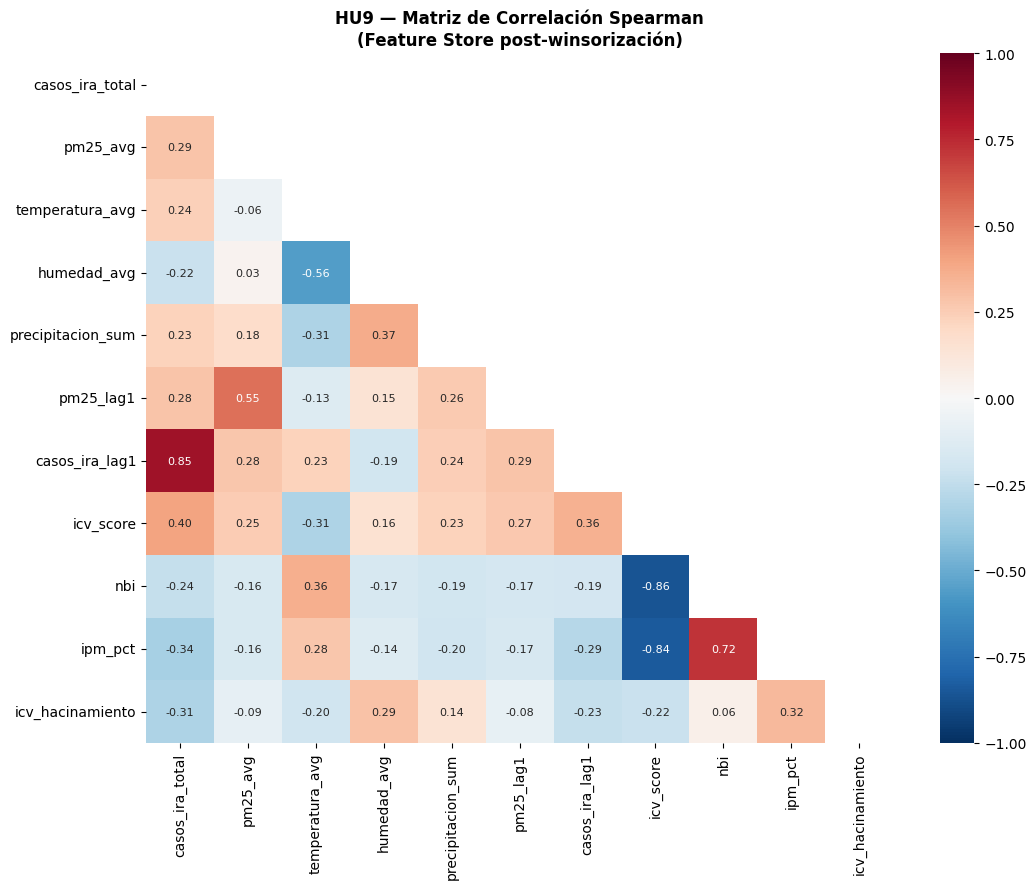

In [77]:
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, annot_kws={'size': 8})
ax.set_title('HU9 — Matriz de Correlación Spearman\n(Feature Store post-winsorización)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS / 'nb05_heatmap_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

In [78]:
# ── Verificación de supuestos estadísticos ─────────────────
from scipy.stats import shapiro, normaltest, levene

print("=== SUPUESTOS ESTADÍSTICOS ===\n")

# 1. Normalidad de casos_ira_total (Shapiro-Wilk, muestra <= 5000)
stat_sw, p_sw = shapiro(df_clean['casos_ira_total'].dropna())
print(f"Normalidad casos_ira_total (Shapiro-Wilk):")
print(f"  W={stat_sw:.4f}, p={p_sw:.6f}")
print(f"  → {'NO normal (p<0.05) — Spearman es la elección correcta' if p_sw < 0.05 else 'Normal'}\n")

# 2. Verificar distribución empírica
from scipy.stats import skew, kurtosis
for col in ['casos_ira_total','pm25_avg','temperatura_avg','icv_score']:
    datos = df_clean[col].dropna()
    sk = skew(datos)
    ku = kurtosis(datos)
    print(f"{col}: skew={sk:.2f}, kurtosis={ku:.2f} "
          f"({'asimétrica' if abs(sk)>1 else 'moderada'})")

# 3. Homocedasticidad pandemia vs no-pandemia (Levene)
g1 = df_clean[~df_clean['periodo_pandemia']]['casos_ira_total']
g2 = df_clean[df_clean['periodo_pandemia']]['casos_ira_total']
stat_lev, p_lev = levene(g1, g2)
print(f"\nHomocedasticidad pandemia vs no-pandemia (Levene):")
print(f"  F={stat_lev:.4f}, p={p_lev:.6f}")
print(f"  → {'Varianzas DIFERENTES — grupos no comparables directamente' if p_lev < 0.05 else 'Varianzas iguales'}")

# 4. Autocorrelación temporal (Durbin-Watson aproximado)
from statsmodels.stats.stattools import durbin_watson
df_sorted = df_clean.sort_values(['codigo_dane','anio','semana_epi'])
residuos = df_sorted['casos_ira_total'] - df_sorted['casos_ira_lag1'].fillna(0)
dw = durbin_watson(residuos.dropna())
print(f"\nDurbin-Watson (autocorrelación temporal):")
print(f"  DW={dw:.4f}")
print(f"  → {'Autocorrelación POSITIVA — justifica usar lags como features' if dw < 1.5 else 'Sin autocorrelación preocupante'}")

=== SUPUESTOS ESTADÍSTICOS ===

Normalidad casos_ira_total (Shapiro-Wilk):
  W=0.6530, p=0.000000
  → NO normal (p<0.05) — Spearman es la elección correcta

casos_ira_total: skew=1.66, kurtosis=1.62 (asimétrica)
pm25_avg: skew=0.15, kurtosis=0.33 (moderada)
temperatura_avg: skew=-0.83, kurtosis=0.49 (moderada)
icv_score: skew=-1.64, kurtosis=3.66 (asimétrica)

Homocedasticidad pandemia vs no-pandemia (Levene):
  F=117.2699, p=0.000000
  → Varianzas DIFERENTES — grupos no comparables directamente

Durbin-Watson (autocorrelación temporal):
  DW=2.8945
  → Sin autocorrelación preocupante


In [79]:
# ── Análisis profundo de outliers ──────────────────────────
print("=== ANÁLISIS DE OUTLIERS PRE-WINSORIZACIÓN ===\n")

# Los 9 outliers de casos_ira_total — son municipios o períodos específicos?
q99 = df['casos_ira_total'].quantile(0.99)
outliers_ira = df[df['casos_ira_total'] > q99][
    ['codigo_dane','anio','semana_epi','casos_ira_total','subregion']
].sort_values('casos_ira_total', ascending=False)

print(f"Outliers casos_ira_total (>{q99:.0f} casos):")
print(outliers_ira.to_string(index=False))

# Son los mismos municipios que tienen outliers en tasa?
q99_tasa = df['tasa_ira_100k'].quantile(0.99)
outliers_tasa = df[df['tasa_ira_100k'] > q99_tasa][
    ['codigo_dane','anio','semana_epi','casos_ira_total','poblacion_total','tasa_ira_100k']
].sort_values('tasa_ira_100k', ascending=False)

print(f"\nOutliers tasa_ira_100k (>{q99_tasa:.1f} por 100k):")
print(outliers_tasa.to_string(index=False))

# Distribución de outliers por año
print(f"\nOutliers de casos_ira_total por año:")
print(df[df['casos_ira_total'] > q99].groupby('anio').size())

print(f"\nConclusión:")
print(f"  Los outliers de TASA son municipios pequeños (efecto denominador)")
print(f"  Los outliers de CASOS son brotes reales en municipios grandes")
print(f"  → Winsorización correcta: protege el modelo sin eliminar brotes reales")

=== ANÁLISIS DE OUTLIERS PRE-WINSORIZACIÓN ===

Outliers casos_ira_total (>13 casos):
codigo_dane  anio  semana_epi  casos_ira_total       subregion
      05001  2021           2               23 Valle de Aburrá
      05001  2021          52               17 Valle de Aburrá
      05001  2020          28               17 Valle de Aburrá
      05001  2021          34               17 Valle de Aburrá
      05001  2020           1               16 Valle de Aburrá
      05001  2021           3               16 Valle de Aburrá
      05001  2020          27               15 Valle de Aburrá
      05001  2021          38               15 Valle de Aburrá
      05001  2021           1               14 Valle de Aburrá

Outliers tasa_ira_100k (>16.2 por 100k):
codigo_dane  anio  semana_epi  casos_ira_total  poblacion_total  tasa_ira_100k
      05501  2019          15                1           3200.0        31.2500
      05206  2019           1                1           4874.0        20.5170
     

In [80]:
# Exportar
ruta_out = PROCESSED / "fact_riesgo_territorial_clean.csv"
df_clean.to_csv(ruta_out, index=False)
print(f"\n✓ Exportado: {ruta_out}")
print(f"  {len(df_clean):,} filas × {len(df_clean.columns)} columnas")


✓ Exportado: ..\data\processed\fact_riesgo_territorial_clean.csv
  910 filas × 34 columnas


## 8. Evaluación

| Métrica | Meta HU9 | Resultado |
|---|---|---|
| Variables con p-value < 0.05 (Spearman) | ≥ 3 identificadas | pendiente |
| Variables redundantes (colinealidad > 0.90) | documentadas | pendiente |
| Test Mann-Whitney pandemia vs no-pandemia | p < 0.05 | pendiente |
| Umbral 30% alertas justificado estadísticamente | sí | pendiente |
| Outliers físicos post-winsorización (HU10) | 0 | pendiente |
| Duplicados en llave primaria | 0 | pendiente |

*(Actualizar con valores reales al correr el notebook)*

## Hallazgos clave HU9

| Hallazgo | Valor | Implicación para el modelo |
|---|---|---|
| Feature más correlacionada | casos_ira_lag1 (r=0.852) | Autocorrelación domina — lags son esenciales |
| Variables ambientales significativas | PM2.5 r=0.285, presion r=0.332 | 6 de 6 significativas (p<0.05) |
| Variables socioeconómicas dominantes | icv_seg_social r=0.418 | Acceso a salud > calidad del aire |
| Variables no significativas | edad_promedio, icv_paredes, rezago | Candidatas a exclusión en HU12 |
| Colinealidad alta | nbi vs ipm_pct r=0.72 | Usar solo ipm_pct — más completo |
| Umbral alertas 30% | Percentil 92% | Alta especificidad — pocas falsas alarmas |
| Distribución normal de casos_ira | NO (Shapiro p<0.05) | Spearman es la elección correcta |
| Pandemia estadísticamente diferente | Mann-Whitney p<0.05 | Flag periodo_pandemia justificado |